## Investigating $\gamma$ for Fluorine
We are repeating the same steps from B4, but using Fluorine compounds instead of water.

We have the **optional** task of investigatin gthe effects of different viscoities and looking at $D_2 O$.

Recall that $\gamma_{fluorine} = 2.517 \times 10^8 rads/sec$ Tesla 

In [218]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd
from pathlib import Path
from helper import *
from uncertainties import ufloat

In [219]:
# CONFIG
data_dir_path = "/B5 Data/" # Change this between notebooks

TEST_DIR = False

data_dict = { # TODO: Switch with our actual data values
# "-0.03": [1.612, 1.607, 1.607],
"0": [1.557, 1.564, 1.565],
".03": [1.687, 1.692, 1.687],
".06": [1.793, 1.796, 1.801],
".09": [1.936, 1.919, 1.926],
".12": [2.013, 2.005, 2.025],
".15": [2.123, 2.126, 2.116],
".18": [2.227, 2.214, 2.248],
".21": [2.362, 2.355, 2.351],
".24": [2.4, 2.409, 2.397],
".27": [2.547, 2.539, 2.556],
".3": [2.678, 2.652, 2.668],
}

In [220]:
# DIR CONFIG
base_dir_path = str(Path.cwd())
DATA_DIR = base_dir_path + data_dir_path
TEST_CSV = "T0059.CSV"

if TEST_DIR == True:
    print("Test Path: ", DATA_DIR + TEST_CSV)
    df = pd.read_csv(DATA_DIR + TEST_CSV, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
    print("Data frame loaded!")

In [221]:
if TEST_DIR == True:
    test_csv = TEST_CSV
    df_test = pd.read_csv(DATA_DIR + test_csv, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
    df_test = df_test.apply(pd.to_numeric, errors='coerce') # Foce data types from strings to numbers

    # Look at the df
    x = df_test["CH1"].to_numpy()
    y = df_test["CH2"].to_numpy()
    t = df_test["TIME"].to_numpy()

    # Verify
    print(df_test.dtypes)
    print(df_test.head())

In [222]:
if TEST_DIR == True:
    # Find index where t = 0
    idx = find_closest_index(df_test, column_name = 'TIME')
    print(f"The index closest to 0 is: {idx}")

In [223]:
if TEST_DIR == True:
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Example Waveforms')

    # Plot CSV Data on ax1

    # Plot CH1 (Signal)
    ax1.plot(t, x, label='Amplifier Output', 
                        color='blue')
    # Plot CH2 (Averaged Max)
    ax1.plot(t, y, label='Averaged Max Output', 
                        color='green')
    # Plot Trigger Point
    ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
    ax1.set_ylabel("Voltage (V)")
    ax1.set_xlabel("Time (s)")
    ax1.legend()

    # Plot Image on ax2
    img = plt.imread(DATA_DIR + "T0052.png")
    ax2.imshow(img)
    ax2.set_title("Phase Plot from Oscilloscope")
    ax2.axis('off')

    plt.show()

In [224]:
if TEST_DIR == True:
    start = idx # Set start index at trigger point
    end = start + 2000 # Set end index

    t_subset = t[start:end]
    x_subset = x[start:end]

    # For initial guess, do FFT
    y_fft = np.fft.rfft(x_subset)
    # print(y_fft)
    y_fft = np.fft.rfft(x_subset)
    freqs = np.fft.rfftfreq(len(t_subset), d=(t_subset[1] - t_subset[0]))
    fft_frequency = freqs[np.argmax(np.abs(y_fft))]
    print(f"Fast Fourier Transform Frequency: {fft_frequency:.2f} Hz")


    # Fit to a sine model
    freq = fft_frequency * 2 * np.pi # TODO: Figure out why this needs to be multiplied by 2pi
    def sine_fcn(B, x):
        return B[0] * np.sin(freq * x + B[1])
    sine_model = odr.Model(sine_fcn)

    mydata = odr.RealData(t_subset, x_subset)

    sol = odr.ODR(mydata, sine_model, beta0=[0.4, 0])
    myoutput = sol.run()
    # myoutput.pprint()

In [225]:
if TEST_DIR == True:
    # Plot to see if the FFT frequency is close
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
    fig.suptitle('Frequency of EMF Signal')

    ax1.plot(t[start:end], x[start:end], label='label', 
                        color='blue')
    ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
    ax1.legend()
    ax1.set_ylabel("Voltage (V)")
    ax1.set_xlabel("Time (s)")

    # Plot fitted sine wave
    fitted_x = sine_fcn(myoutput.beta, t_subset)
    ax1.plot(t_subset, fitted_x)

# Process Data

In [226]:
current_data = []
freq_means = []
freq_stds = []

for current, freqs in data_dict.items():
    # Look at each of the three CSV's
    current_data.append(eval(current))
    freq_means.append(np.mean(freqs))
    freq_stds.append(np.std(freqs))

current_data = np.array(current_data)
print(current_data)
print(freq_means)
print(freq_stds)

[0.   0.03 0.06 0.09 0.12 0.15 0.18 0.21 0.24 0.27 0.3 ]
[np.float64(1.562), np.float64(1.6886666666666665), np.float64(1.7966666666666666), np.float64(1.9269999999999998), np.float64(2.014333333333333), np.float64(2.1216666666666666), np.float64(2.2296666666666667), np.float64(2.3560000000000003), np.float64(2.4019999999999997), np.float64(2.5473333333333334), np.float64(2.666)]
[np.float64(0.0035590260840104608), np.float64(0.002357022603955108), np.float64(0.0032998316455372175), np.float64(0.0069761498454854135), np.float64(0.008219218670625309), np.float64(0.004189935029992117), np.float64(0.014007934259633911), np.float64(0.004546060565662004), np.float64(0.005099019513592775), np.float64(0.006944222218666513), np.float64(0.0107082522694726)]


In [227]:
# Error for currents
def multimeter_uncerts(val):
    """
    All vals are in 10A to 10mA range
    """
    return val * 0.02 + 0.01

current_uncerts = multimeter_uncerts(current_data)

In [228]:
# Fit the data
def linear_fcn(B, x):
    return B[0] * x + B[1]
linear_model = odr.Model(linear_fcn)

mydata = odr.RealData(current_data, freq_means, sx= current_uncerts, sy = freq_stds / np.sqrt(3))

sol = odr.ODR(mydata, linear_model, beta0=[0.4, 0])
myoutput = sol.run()
myoutput.pprint()

Beta: [3.6144187  1.57738313]
Beta Std Error: [0.05662255 0.00867775]
Beta Covariance: [[ 0.02183029 -0.00265798]
 [-0.00265798  0.00051274]]
Residual Variance: 0.14686533275712768
Inverse Condition #: 0.3081069330214228
Reason(s) for Halting:
  Sum of squares convergence


<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:26: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_43641/2168052532.py:26: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"


Text(0.67, 0.3, 'Slope: 3.614 ± 0.057\nIntercept: 1.577 ± 0.009\n$\\chi^2_{red}$: 0.15')

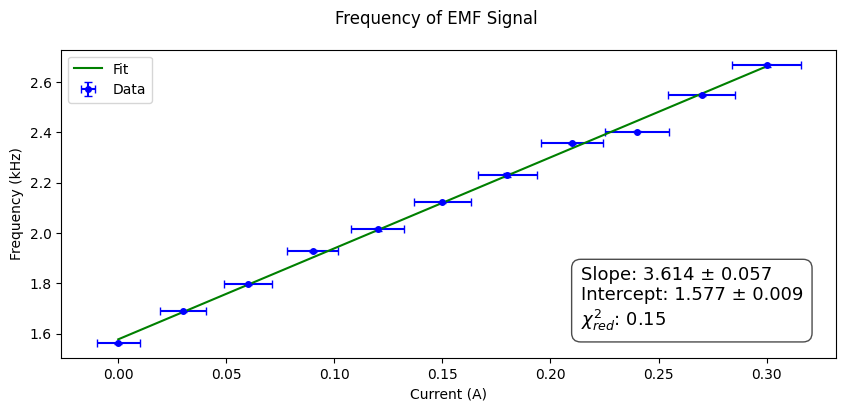

In [229]:
# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

# ax1.scatter(current_data, freq_means, label='label', color='blue')

ax1.errorbar(current_data, freq_means, xerr = current_uncerts, yerr = freq_stds / np.sqrt(3), fmt='o',
                    color='blue', label='Data', capsize=3, markersize=4)

# Plot best fit
ax1.plot(np.array(current_data), linear_fcn(myoutput.beta, np.array(current_data)), label = 'Fit', color = 'green')
ax1.legend()
ax1.set_ylabel("Frequency (kHz)")
ax1.set_xlabel("Current (A)")

slope = myoutput.beta[0]
slope_error = myoutput.sd_beta[0]
intercept = myoutput.beta[1]
intercept_error = myoutput.sd_beta[1]
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square
stats_text = (
    f"Slope: {slope:.3f} ± {slope_error:.3f}\n"
    f"Intercept: {intercept:.3f} ± {intercept_error:.3f}\n"
    # f"$\chi^2$: {chi_sq:.3f}\n"
    f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"
)
plt.text(0.67, 0.3, stats_text, transform=plt.gca().transAxes, 
         fontsize=13, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

In [230]:
R = 0.307
N = 30
mu_0 = (4 * np.pi) * 10**(-7)
slope * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi # multiply by 1000 from kHz to Hz


# Don't forget to convert from Hz to rads/second
gamma_proton = slope * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi # multiply by 1000 from kHz to Hz
gamma_proton_error = slope_error * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi
# print(f"Gyromagnetic Ratio for proton: {gamma_proton:.4e} rads/second Tesla")

gamma_final = ufloat(gamma_proton, gamma_proton_error)
print(f"Gyromagnetic Ratio for proton: {gamma_final:.4e} rads/second Tesla")
print(f"Which is approximately 2-3 sigma away.")

Gyromagnetic Ratio for proton: (2.5846+/-0.0405)e+08 rads/second Tesla
Which is approximately 2-3 sigma away.


In [231]:
# When propogating, errors, look at formula
# N should have no error
# mu_0 has a very small, negligible error (relative error of 10^-10)
# R should have a small error
# Dominant errors include the error in slope 
# mu_0
# Uncertainty in meterstick is estimated to be smallest discretization (mm) /2, which is much smaller than uncertainty in slope

.001 / 2

0.0005

## Looking at Deuterium

In [232]:

deu_data_dict = {
"2.29": [1.578, 1.569, 1.607],
"2.4": [1.689, 1.736, 1.68]
}

current_data = []
freq_means = []
freq_stds = []

for current, freqs in deu_data_dict.items():
    # Look at each of the three CSV's
    current_data.append(eval(current))
    freq_means.append(np.mean(freqs))
    freq_stds.append(np.std(freqs))

current_data = np.array(current_data)
print(current_data)
print(freq_means)
print(freq_stds)

[2.29 2.4 ]
[np.float64(1.584666666666667), np.float64(1.7016666666666664)]
[np.float64(0.016213848676020413), np.float64(0.02455379581427053)]


In [ ]:
def multimeter_uncerts(val): # TODO: UPDATE FOR NEW MUTLIMETER
    """
    All vals are in 10A to 10mA range
    """
    return val * 0.002 + 0.0001

current_uncerts = multimeter_uncerts(current_data)

In [234]:
# Fit the data
def linear_fcn(B, x):
    return B[0] * x + B[1]
linear_model = odr.Model(linear_fcn)

mydata = odr.RealData(current_data, freq_means, sx= current_uncerts, sy = freq_stds)

sol = odr.ODR(mydata, linear_model, beta0=[0.4, 0])
myoutput = sol.run()
myoutput.pprint()

Beta: [ 1.06363636 -0.85106061]
Beta Std Error: [9.03920539e-15 2.10165202e-14]
Beta Covariance: [[ 0.07584433 -0.17629869]
 [-0.17629869  0.41000038]]
Residual Variance: 1.0773017513383618e-27
Inverse Condition #: 0.0009058667672175319
Reason(s) for Halting:
  Parameter convergence


<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:26: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_43641/2168052532.py:26: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"


Text(0.67, 0.3, 'Slope: 1.064 ± 0.000\nIntercept: -0.851 ± 0.000\n$\\chi^2_{red}$: 0.00')

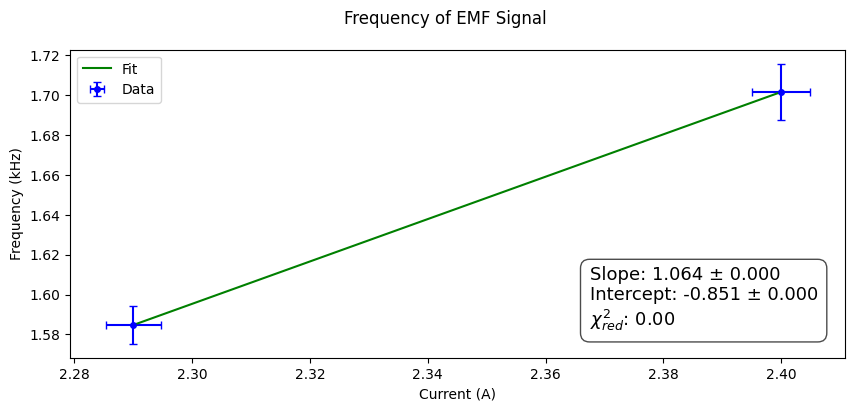

In [235]:
# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

# ax1.scatter(current_data, freq_means, label='label', color='blue')

ax1.errorbar(current_data, freq_means, xerr = current_uncerts, yerr = freq_stds / np.sqrt(3), fmt='o',
                    color='blue', label='Data', capsize=3, markersize=4)

# Plot best fit
ax1.plot(np.array(current_data), linear_fcn(myoutput.beta, np.array(current_data)), label = 'Fit', color = 'green')
ax1.legend()
ax1.set_ylabel("Frequency (kHz)")
ax1.set_xlabel("Current (A)")

slope = myoutput.beta[0]
slope_error = myoutput.sd_beta[0]
intercept = myoutput.beta[1]
intercept_error = myoutput.sd_beta[1]
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square
stats_text = (
    f"Slope: {slope:.3f} ± {slope_error:.3f}\n"
    f"Intercept: {intercept:.3f} ± {intercept_error:.3f}\n"
    # f"$\chi^2$: {chi_sq:.3f}\n"
    f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"
)
plt.text(0.67, 0.3, stats_text, transform=plt.gca().transAxes, 
         fontsize=13, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

In [237]:
R = 0.307
N = 30
mu_0 = (4 * np.pi) * 10**(-7)
slope * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi # multiply by 1000 from kHz to Hz


# Don't forget to convert from Hz to rads/second
gamma_proton = slope * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi # multiply by 1000 from kHz to Hz
gamma_proton_error = slope_error * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi
# print(f"Gyromagnetic Ratio for proton: {gamma_proton:.4e} rads/second Tesla")

gamma_final = ufloat(gamma_proton, gamma_proton_error)
print(f"Gyromagnetic Ratio for proton: {gamma_final:.4e} rads/second Tesla")

Gyromagnetic Ratio for proton: (7.6058+/-0.0000)e+07 rads/second Tesla
